Libraries imported successfully.

DATASET INFORMATION
Dataset loaded successfully.
Rows: 284807
Columns: 31

First five rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



CLASS DISTRIBUTION
Normal transactions: 284315
Fraudulent transactions: 492
Fraud percentage: 0.1727%

TRAIN / TEST SPLIT
Training records: 199364
Testing records: 85443

Feature scaling completed successfully.
Contamination rate: 0.001727

MODEL TRAINING
Training PyOD AutoEncoder...
Training may take several minutes.


Training: 100%|█████████████████████████████████████████████| 10/10 [01:35<00:00,  9.50s/it]



AutoEncoder training completed successfully.
Predictions completed successfully.

FRAUD DETECTION RESULTS
Precision: 0.2403
Recall:    0.2095
F1 Score:  0.2238
ROC-AUC:   0.9472

Confusion Matrix:
[[85197    98]
 [  117    31]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Fraud       0.24      0.21      0.22       148

    accuracy                           1.00     85443
   macro avg       0.62      0.60      0.61     85443
weighted avg       1.00      1.00      1.00     85443


CONFUSION MATRIX DETAILS
True Negatives : 85197
False Positives: 98
False Negatives: 117
True Positives : 31


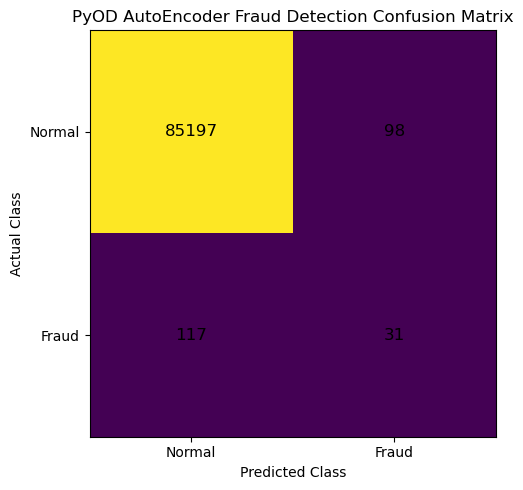

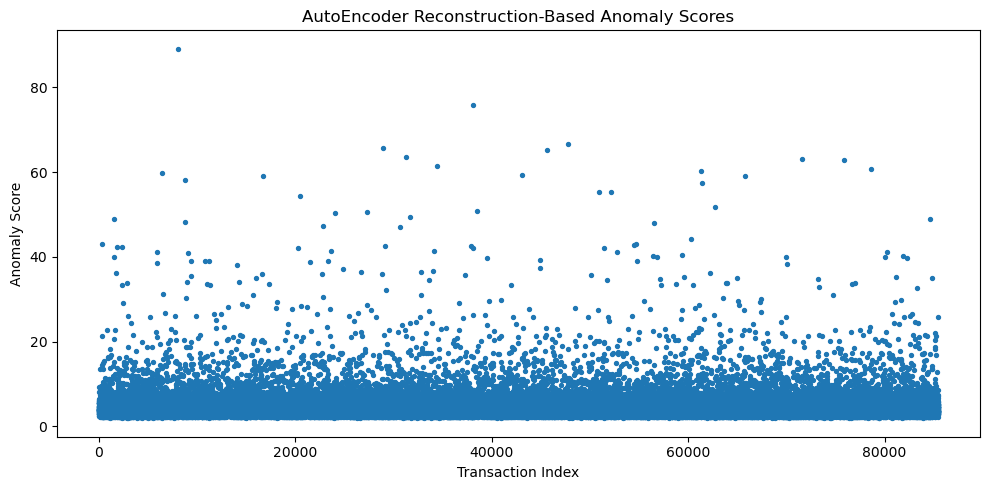


FRAUD COUNT COMPARISON
Actual fraud transactions in test set: 148
Transactions flagged as anomalies: 129
Correctly detected fraud cases: 31
Fraud cases missed by model: 117

EXPERIMENT SUMMARY


,Metric,Result
0,Precision,0.2403
1,Recall,0.2095
2,F1 Score,0.2238
3,ROC-AUC,0.9472
4,True Negatives,85197.0000
5,False Positives,98.0000
6,False Negatives,117.0000
7,True Positives,31.0000
8,Actual Fraud Cases,148.0000
9,Flagged Fraud Cases,129.0000



TEXT FOR WORD DOCUMENT

An unsupervised fraud-detection model was developed using the PyOD AutoEncoder algorithm and the anonymized credit-card transaction dataset. The Class variable was excluded from training and was used only afterward to evaluate the model's ability to identify fraudulent transactions.

The dataset contained 284,807 transactions, including 492 fraudulent transactions. Fraud represented approximately 0.1727% of the complete dataset.

The trained AutoEncoder achieved a precision of 0.2403, recall of 0.2095, F1 score of 0.2238, and ROC-AUC of 0.9472.

The test set contained 148 actual fraud cases. The model correctly detected 31 fraudulent transactions and missed 117. It also produced 98 false-positive fraud alerts.

The experiment demonstrates how an AutoEncoder can learn patterns representing normal transaction behavior without using the fraud labels during training. Transactions that are reconstructed poorly receive larger anomaly scores and can therefore be ident

In [3]:
# ============================================================
# FRAUD DETECTION USING PYOD AUTOENCODER
# Unsupervised Deep Learning Experiment
# Dataset: creditcard.csv
# ============================================================

# ------------------------------------------------------------
# 1. Import libraries
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyod.models.auto_encoder import AutoEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

print("Libraries imported successfully.")


# ------------------------------------------------------------
# 2. Load the dataset
# ------------------------------------------------------------
DATA_FILE = "creditcard.csv"

df = pd.read_csv(DATA_FILE)

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nFirst five rows:")
display(df.head())


# ------------------------------------------------------------
# 3. Check class distribution
# ------------------------------------------------------------
normal_count = int((df["Class"] == 0).sum())
fraud_count = int((df["Class"] == 1).sum())

fraud_rate = fraud_count / len(df)

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

print("Normal transactions:", normal_count)
print("Fraudulent transactions:", fraud_count)
print(f"Fraud percentage: {fraud_rate * 100:.4f}%")


# ------------------------------------------------------------
# 4. Separate features and true labels
# ------------------------------------------------------------
# IMPORTANT:
# The 'Class' column is NOT used when training the AutoEncoder.
# It is used only afterward to evaluate the detected anomalies.

X = df.drop(columns=["Class"])
y = df["Class"].astype(int)


# ------------------------------------------------------------
# 5. Split data into training and testing sets
# ------------------------------------------------------------
# Stratification keeps approximately the same fraud percentage
# in the training and testing sets.

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training records:", len(X_train_raw))
print("Testing records:", len(X_test_raw))


# ------------------------------------------------------------
# 6. Standardize the features
# ------------------------------------------------------------
# Fit the scaler only on training data to avoid data leakage.

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("\nFeature scaling completed successfully.")


# ------------------------------------------------------------
# 7. Define contamination
# ------------------------------------------------------------
# Contamination is the approximate expected proportion of
# anomalies in the dataset.
#
# The known fraud percentage is used only to configure the
# unsupervised threshold. Class labels are not given to fit().

contamination = fraud_rate

print(f"Contamination rate: {contamination:.6f}")


# ------------------------------------------------------------
# 8. Create the PyOD AutoEncoder
# ------------------------------------------------------------
model = AutoEncoder(
    contamination=contamination,
    hidden_neuron_list=[32, 16, 8, 16, 32],
    epoch_num=10,
    batch_size=256,
    lr=0.001,
    verbose=1,
    random_state=42
)

print("\n" + "=" * 60)
print("MODEL TRAINING")
print("=" * 60)

print("Training PyOD AutoEncoder...")
print("Training may take several minutes.")


# ------------------------------------------------------------
# 9. Train the model
# ------------------------------------------------------------
model.fit(X_train)

print("\nAutoEncoder training completed successfully.")


# ------------------------------------------------------------
# 10. Predict anomalies on the test set
# ------------------------------------------------------------
# Prediction values:
# 0 = normal
# 1 = anomaly / suspected fraud

y_pred = model.predict(X_test)

# Continuous anomaly scores.
# Larger scores indicate more unusual transactions.

decision_scores = model.decision_function(X_test)

print("Predictions completed successfully.")


# ------------------------------------------------------------
# 11. Calculate performance metrics
# ------------------------------------------------------------
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    decision_scores
)

cm = confusion_matrix(
    y_test,
    y_pred
)


# ------------------------------------------------------------
# 12. Print fraud detection results
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("FRAUD DETECTION RESULTS")
print("=" * 60)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)


# ------------------------------------------------------------
# 13. Extract confusion-matrix values
# ------------------------------------------------------------
tn, fp, fn, tp = cm.ravel()

print("\n" + "=" * 60)
print("CONFUSION MATRIX DETAILS")
print("=" * 60)

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


# ------------------------------------------------------------
# 14. Create confusion-matrix chart
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("PyOD AutoEncoder Fraud Detection Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    ["Normal", "Fraud"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Fraud"]
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=12
        )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 15. Plot anomaly scores
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.scatter(
    np.arange(len(decision_scores)),
    decision_scores,
    s=8
)

plt.title("AutoEncoder Reconstruction-Based Anomaly Scores")
plt.xlabel("Transaction Index")
plt.ylabel("Anomaly Score")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 16. Compare actual and detected fraud
# ------------------------------------------------------------
actual_fraud = int(y_test.sum())
flagged_fraud = int(y_pred.sum())

print("\n" + "=" * 60)
print("FRAUD COUNT COMPARISON")
print("=" * 60)

print("Actual fraud transactions in test set:", actual_fraud)
print("Transactions flagged as anomalies:", flagged_fraud)
print("Correctly detected fraud cases:", tp)
print("Fraud cases missed by model:", fn)


# ------------------------------------------------------------
# 17. Create summary table
# ------------------------------------------------------------
summary = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives",
        "Actual Fraud Cases",
        "Flagged Fraud Cases"
    ],
    "Result": [
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(roc_auc, 4),
        tn,
        fp,
        fn,
        tp,
        actual_fraud,
        flagged_fraud
    ]
})

print("\n" + "=" * 60)
print("EXPERIMENT SUMMARY")
print("=" * 60)

display(summary)


